In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

llm = ChatOpenAI(model="gpt-4.1", temperature=0)
small_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = PineconeVectorStore(
    index_name="inhouse-python-index",
    embedding=embeddings,
)

retriever = vector_store.as_retriever()


In [7]:
from langgraph.graph import StateGraph, MessagesState

graph_builder = StateGraph(MessagesState)

In [8]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool
from langchain_core.documents import Document
from pydantic import BaseModel

class checkFaqResponse(BaseModel):
  is_in_faq: bool
  context: list[Document]

@tool
def check_faq(question: str)-> checkFaqResponse:
  """Check if the question is in the FAQ.
  If the question is in the FAQ, return the context of the question.
  Otherwise, return an empty list.
  """
  context = retriever.invoke(question, filter={"source":"employee_benefits_and_welfare_faq"})
  check_faq_prompt = ChatPromptTemplate.from_messages([
    ("system","""You are a helpful assistant that checks if the question is in the FAQ. 
     If the question is in the FAQ, return 'Yes'. Otherwise, return 'No'."""),
    ("user","Question: {question}\nContext:{context}"),
  ])  
  
  check_faq_chain = check_faq_prompt | llm | StrOutputParser()
  is_in_faq = check_faq_chain.invoke({"question":question,"context":context})
  return {"is_in_faq": is_in_faq == "Yes","context":context}

In [9]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate 
from langchain_core.output_parsers import StrOutputParser

@tool
def get_document_name(question: str) -> str:
    """Get the document name based on the question."""
    determine_document_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """You are a helpful assistant that determines the most relevant document name based on the user's question. 
Choose from the following document names:
- delegation_of_authority
- employee_benefits_and_welfare_faq
- employee_benefits_and_welfare_guide
- employee_handbook_and_hr_policy
- expense_management_guide
- it_support_guide
- legal_and_compliance_policy

Return ONLY the document name (e.g., 'it_support_guide').

Examples:
- If the question is about who can approve expenses, return 'delegation_of_authority' or 'expense_management_guide' as appropriate.
- If the question is about employee benefits, return 'employee_benefits_and_welfare_guide'.
- If the question is about HR policies or the employee handbook, return 'employee_handbook_and_hr_policy'.
- If the question is about IT support or technical issues, return 'it_support_guide'.
- If the question is about legal or compliance matters, return 'legal_and_compliance_policy'.
- If the question is a frequently asked question about benefits, return 'employee_benefits_and_welfare_faq'.
"""),
        ("user", "Question: {question}"),
    ]
)
    determine_document_chain = determine_document_prompt | llm | StrOutputParser()
    document_name = determine_document_chain.invoke({"question": question})
    return document_name

In [10]:
from typing import List
from langchain_core.tools.retriever import create_retriever_tool

@tool
def retriever_tool(question:str, document_name: str) -> List[Document]:
    """Retrieve the document based on the question and document name."""
    context = retriever.invoke(question, filter={"source": document_name})
    return context

# retriever_tool = create_retriever_tool(
#     retriever, 
#     "company_document_retriever",
#     """사내 문서 모음에서 정보를 찾아주는 도구입니다. 문서 이름을 기반으로 source에 필터링을 한 후에, page_content를 반환합니다."""
# )

In [11]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model="openai:gpt-4.1",
    tools=[retriever_tool, check_faq, get_document_name],
    prompt="Use the tools provided to you to answer the user's question",
)

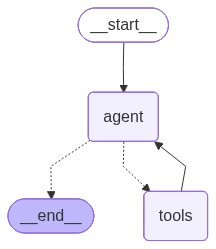

In [16]:
agent

In [17]:
from langchain_core.messages import HumanMessage

for chunk in agent.stream({"messages": [HumanMessage(content="사내 네트워크 담당자는 누구인가요?")]}, stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

사내 네트워크 담당자는 누구인가요?
================================== Ai Message ==================================
Tool Calls:
  check_faq (call_RQFgEwVARZ3flMjkMrrvo88Z)
 Call ID: call_RQFgEwVARZ3flMjkMrrvo88Z
  Args:
    question: 사내 네트워크 담당자는 누구인가요?
================================= Tool Message =================================
Name: check_faq

{'is_in_faq': False, 'context': [Document(id='4fd5db88-641f-41e9-9903-c7910e075dfd', metadata={'source': 'employee_benefits_and_welfare_faq'}, page_content='직원 복리후생 및 복지 FAQ\n======================  \n1. 연차 유급 휴가 관련\n------------------  \nQ1: 연차 휴가는 어떻게 사용하나요?\n* A: 연차 휴가는 본인 승인을 통해 자유롭게 사용할 수 있으며, 사내 HR 시스템에서 신청 가능합니다.  \nQ2: 연차는 어떻게 계산되나요?\n* A: 근속 연수에 따라 차등 지급되며, 1년 미만은 월 1일, 1~3년은 15일, 10년 이상은 20일입니다.  \nQ3: 미사용 연차는 어떻게 처리되나요?\n* A: 연차는 해당 연도에 사용해야 하며, 이월은 불가합니다.  \n2. 출산 및 육아 휴가 관련\n---------------------  \nQ4: 출산 휴가는 언제부터 사용할 수 있나요?\n* A: 출산 예정일 전후로 자유롭게 사용할 수 있으며, 최대 

In [18]:
for chunk in agent.stream({"messages": [HumanMessage(content="전결 규정을 알려주세요")]}, stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

전결 규정을 알려주세요
================================== Ai Message ==================================
Tool Calls:
  check_faq (call_pIynkrJpwG9KS8fSI3BOHBUS)
 Call ID: call_pIynkrJpwG9KS8fSI3BOHBUS
  Args:
    question: 전결 규정
================================= Tool Message =================================
Name: check_faq

{'is_in_faq': False, 'context': [Document(id='4fd5db88-641f-41e9-9903-c7910e075dfd', metadata={'source': 'employee_benefits_and_welfare_faq'}, page_content='직원 복리후생 및 복지 FAQ\n======================  \n1. 연차 유급 휴가 관련\n------------------  \nQ1: 연차 휴가는 어떻게 사용하나요?\n* A: 연차 휴가는 본인 승인을 통해 자유롭게 사용할 수 있으며, 사내 HR 시스템에서 신청 가능합니다.  \nQ2: 연차는 어떻게 계산되나요?\n* A: 근속 연수에 따라 차등 지급되며, 1년 미만은 월 1일, 1~3년은 15일, 10년 이상은 20일입니다.  \nQ3: 미사용 연차는 어떻게 처리되나요?\n* A: 연차는 해당 연도에 사용해야 하며, 이월은 불가합니다.  \n2. 출산 및 육아 휴가 관련\n---------------------  \nQ4: 출산 휴가는 언제부터 사용할 수 있나요?\n* A: 출산 예정일 전후로 자유롭게 사용할 수 있으며, 최대 20일 유급으로 제공됩니다.  \nQ5